# Previsão Precisão Linear

P = b + m * v

Legenda:
 
 P = N° a ser previsto (y)

 b = Intersecção, o valor de y que a reta corta o eixo y

 m = inclinação
 
 v = valor de x a ser previsto

# Calcular CV:
cv = somatorio((xi - mediax) * (yi - mediay)) / numero de elementos

# Calcular CR:
cr = cv / (Std(y) * Std(x))

# Calcular m:
m = CR * (Std(y) / Std(x))

# Calcular b:
b = média y - média x * m

In [715]:
import pandas as pd
import numpy as np

df = pd.read_csv('plano_saude.csv')

def funcaoCovariancia(df):
    somatorio = 0
    
    xMedia = np.mean(df['idade'])
    yMedia = np.mean(df['custo'])
    
    for i in range(len(df)):
        
        x = df['idade'][i]
        y = df['custo'][i]
        
        somatorio += (x - xMedia) * (y - yMedia)
        
    covariancia = somatorio / (len(df) - 1)
    
    return covariancia

def funcaoCorrelacao(df):
    covariancia = funcaoCovariancia(df)
    
    stdX = np.std(df['idade'], ddof=1)
    stdY = np.std(df['custo'], ddof=1)
    
    correlacao = covariancia / (stdX * stdY)
    
    return correlacao

def funcaoInclinacao(df):
    correlacao = funcaoCorrelacao(df)
    
    stdX = np.std(df['idade'], ddof=1)
    stdY = np.std(df['custo'], ddof=1)
    
    inclinacao = correlacao * (stdY / stdX)
    
    return inclinacao

def funcaoIntersecao(df):
    inclinacao = funcaoInclinacao(df)
    
    xMedia = np.mean(df['idade'])
    yMedia = np.mean(df['custo'])
    
    intersecao = yMedia - (inclinacao * xMedia)
    
    return intersecao

def preverCusto(df, v):
    intersecao = funcaoIntersecao(df)
    inclinacao = funcaoInclinacao(df)
    
    previsao = intersecao + (inclinacao * v)
    
    return float(previsao)

v = 54

print('Covariância:', funcaoCovariancia(df))
print('Correlação:', funcaoCorrelacao(df))
print('Inclinação:', funcaoInclinacao(df))
print('Interseção:', funcaoIntersecao(df))
print('Previsão:', preverCusto(df, 54))

Covariância: 13056.68181818182
Correlação: 0.9879039537164834
Inclinação: 46.450032341526516
Interseção: 149.0577296248382
Previsão: 2657.3594760672704


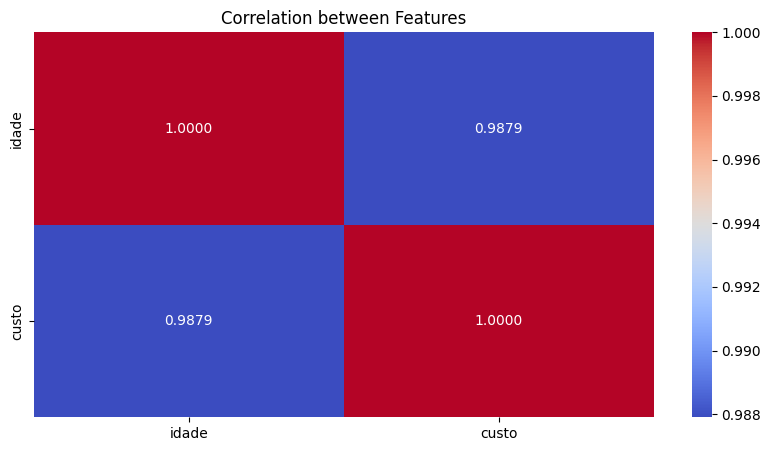

In [716]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".4f")
plt.title('Correlation between Features')
plt.show()

# LinearRegression com Scikit-learn

In [717]:
from sklearn.linear_model import LinearRegression
import pandas as pd

df = pd.read_csv('plano_saude.csv')

x = df['idade'] #feature
y = df['custo'] #target, não está bidimensional ainda: (11, )

x = x.values.reshape(-1, 1) #deixando x bidimensional: (11, 1) -> 11 registros e 1 feature

In [718]:
#criando o objeto de regressão linear
regressor_plano_saude = LinearRegression()

In [719]:
#fazendo o treinamento com .fit
regressor_plano_saude.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[46.45]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,149.1
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[53.02]


In [720]:
#consultando valores
print('b:', regressor_plano_saude.intercept_)
print('m:', regressor_plano_saude.coef_)

b: 149.05772962483752
m: [46.45003234]


In [721]:
#realizando uma previsão
previsao_54_anos = regressor_plano_saude.predict([[54]]) #precisa estar dentro de duas listas, pois o modelo espera uma estrutura bidimensional
print(previsao_54_anos)

[2657.35947607]


In [722]:
#previsoes para toda a base
previsoes = regressor_plano_saude.predict(x)

In [723]:
#avaliando o modelo
regressor_plano_saude.score(x, y)

0.9759542217686598

# LinearRegression com múltiplas features


In [724]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv('house_prices.csv')

x = df[
    [
        'bedrooms',
        'bathrooms',
        'sqft_living',
        'sqft_lot',
        'floors',
        'yr_built'
    ]
]

y = df['price']

In [725]:
modelo = LinearRegression()

In [726]:
modelo.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[-68485.7 , 67514.43, 303.21, -0.3 , 53981.52, -3364.95]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['bedrooms','bathrooms','sqft_living','sqft_lot','floors','yr_built']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.554e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [727]:
coeficientes = pd.DataFrame({
    'Feature': x.columns,
    'Coeficiente': modelo.coef_
})

print(coeficientes)

       Feature   Coeficiente
0     bedrooms -68485.704714
1    bathrooms  67514.433494
2  sqft_living    303.211017
3     sqft_lot     -0.298320
4       floors  53981.518082
5     yr_built  -3364.951129


In [728]:
nova_casa = pd.DataFrame({
    'bedrooms': [3],
    'bathrooms': [2.0],
    'sqft_living': [1800],
    'sqft_lot': [5000],
    'floors': [1.0],
    'yr_built': [1990]
})

previsao = modelo.predict(nova_casa)
print(previsao)

[385283.80222688]


In [729]:
previsoes = modelo.predict(x)
modelo.score(x, y)

0.5562315176036366

In [730]:
df = pd.read_csv('house_prices.csv')

df.drop('date', axis=1, inplace=True)

In [731]:
x_casas = df.iloc[:, 2:18].values
y_casas = df.iloc[:, 1].values

In [732]:
#separando dados de treinamento e teste
x_treinamento, x_teste, y_treinamento, y_teste = train_test_split(x_casas, y_casas, test_size=0.2, random_state=42)

In [733]:
x_treinamento.shape, x_teste.shape

((17290, 16), (4323, 16))

In [734]:
#treinando o algoritmo
modelo = LinearRegression()
modelo.fit(x_treinamento, y_treinamento)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](16,)","[ -34178.21, 44283.58, 113.38,..., -571.41, 600311.08,-185785.88]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,9.426e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(15)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](16,)","[5106964.82, 153800.05, 69009.27,..., 13.71, 10.16, 0. ]"


In [735]:
#medindo a qualidade dos dados de treinamento
modelo.score(x_treinamento, y_treinamento)

0.6983188500566079

In [736]:
#medindo a qualidade dos dados de teste
modelo.score(x_teste, y_teste)

0.6999397683935713

In [737]:
#exemplo de previsão com inputs
nova_casa = np.array([
    [
        3,          # bedrooms
        2.0,        # bathrooms
        1800,       # sqft_living
        5000,       # sqft_lot
        1.0,        # floors
        0,          # waterfront
        0,          # view
        3,          # condition
        7,          # grade
        1800,       # sqft_above
        0,          # sqft_basement
        1990,       # yr_built
        0,          # yr_renovated
        98001,      # zipcode
        47.30,      # lat
        -122.25     # long
    ]
])

preco_previsto = modelo.predict(nova_casa)

print(preco_previsto[0])

253069.3126385901


# MAE e MSE

In [738]:
from sklearn.metrics import mean_absolute_error

previsoes = modelo.predict(x_teste)

mae = mean_absolute_error(
    y_teste,
    previsoes
)

print(f'MAE: {mae}')

MAE: 127744.42981458854


In [739]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    y_teste,
    previsoes
)

print(f'MSE: {mse}')

MSE: 45362119293.29082


# Regressão linear polinomial

In [740]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Carregamento da base
base_casas = pd.read_csv('house_prices.csv')


# Remoção da coluna de data
base_casas.drop(
    'date',
    axis=1,
    inplace=True
)


# Separação das features e do target
X_casas = base_casas.iloc[:, 2:18].values
y_casas = base_casas.iloc[:, 1].values


# Divisão entre treinamento e teste
X_casas_treinamento, X_casas_teste, y_casas_treinamento, y_casas_teste = train_test_split(
    X_casas,
    y_casas,
    test_size=0.2,
    random_state=42
)


# Criação do transformador polinomial
poly = PolynomialFeatures(
    degree=2
)


# Transformação dos dados de treinamento
X_casas_treinamento_poly = poly.fit_transform(
    X_casas_treinamento
)


# Transformação dos dados de teste
X_casas_teste_poly = poly.transform(
    X_casas_teste
)


# Criação do modelo
regressor_casas_poly = LinearRegression()


# Treinamento
regressor_casas_poly.fit(
    X_casas_treinamento_poly,
    y_casas_treinamento
)


# Score de treinamento
score_treinamento_poly = regressor_casas_poly.score(
    X_casas_treinamento_poly,
    y_casas_treinamento
)


# Score de teste
score_teste_poly = regressor_casas_poly.score(
    X_casas_teste_poly,
    y_casas_teste
)


# Previsões
previsoes_poly = regressor_casas_poly.predict(
    X_casas_teste_poly
)


# MAE
mae_poly = mean_absolute_error(
    y_casas_teste,
    previsoes_poly
)


# MSE
mse_poly = mean_squared_error(
    y_casas_teste,
    previsoes_poly
)


# RMSE
rmse_poly = np.sqrt(
    mse_poly
)


# Resultados
print('Formato original do treinamento:')
print(X_casas_treinamento.shape)

print('\nFormato polinomial do treinamento:')
print(X_casas_treinamento_poly.shape)

print('\nScore de treinamento:')
print(score_treinamento_poly)

print('\nScore de teste:')
print(score_teste_poly)

print('\nMAE:')
print(mae_poly)

print('\nMSE:')
print(mse_poly)

print('\nRMSE:')
print(rmse_poly)

Formato original do treinamento:
(17290, 16)

Formato polinomial do treinamento:
(17290, 153)

Score de treinamento:
0.6960468790862415

Score de teste:
0.6399060221785269

MAE:
138941.89270186477

MSE:
54437823670.54374

RMSE:
233319.14552934514


# Decision tree

In [741]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Carregar a base
base_casas = pd.read_csv('house_prices.csv')


# Remover a coluna de data
base_casas.drop(
    'date',
    axis=1,
    inplace=True
)


# Features e target
X_casas = base_casas.iloc[:, 2:18].values
y_casas = base_casas.iloc[:, 1].values


# Separar treinamento e teste
X_casas_treinamento, X_casas_teste, y_casas_treinamento, y_casas_teste = train_test_split(
    X_casas,
    y_casas,
    test_size=0.2,
    random_state=42
)


# Criar o modelo
regressor_arvore_casas = DecisionTreeRegressor()


# Treinar a árvore
regressor_arvore_casas.fit(
    X_casas_treinamento,
    y_casas_treinamento
)


# Avaliar o treinamento
score_treinamento_arvore = regressor_arvore_casas.score(
    X_casas_treinamento,
    y_casas_treinamento
)


# Avaliar o teste
score_teste_arvore = regressor_arvore_casas.score(
    X_casas_teste,
    y_casas_teste
)


# Fazer previsões
previsoes_arvore = regressor_arvore_casas.predict(
    X_casas_teste
)


# Calcular MAE
mae_arvore = mean_absolute_error(
    y_casas_teste,
    previsoes_arvore
)


# Calcular MSE
mse_arvore = mean_squared_error(
    y_casas_teste,
    previsoes_arvore
)


# Calcular RMSE
rmse_arvore = np.sqrt(
    mse_arvore
)


# Exibir resultados
print('Score de treinamento:')
print(score_treinamento_arvore)

print('\nScore de teste:')
print(score_teste_arvore)

print('\nMAE:')
print(mae_arvore)

print('\nMSE:')
print(mse_arvore)

print('\nRMSE:')
print(rmse_arvore)

Score de treinamento:
0.9992343746075667

Score de teste:
0.716092780866145

MAE:
104582.82569974555

MSE:
42920159974.64313

RMSE:
207171.81269333704


In [742]:
from sklearn.tree import DecisionTreeRegressor

modelo_decisiontree = DecisionTreeRegressor()

modelo_decisiontree.fit(X_casas_treinamento, y_casas_treinamento)

,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_node

In [743]:
modelo_decisiontree.score(
    X_casas_treinamento,
    y_casas_treinamento
)

0.9992343746075667

In [744]:
modelo_decisiontree.score(
    X_casas_teste,
    y_casas_teste
)

0.7028221558041405

In [745]:
previsoes_arvore = modelo_decisiontree.predict(
    X_casas_teste
)

comparacao_arvore = pd.DataFrame({
    'Preço real': y_casas_teste,
    'Preço previsto': previsoes_arvore
})

comparacao_arvore.head()

,Preço real,Preço previsto
0,365000.0,397500.0
1,865000.0,696000.0
2,1038000.0,1225000.0
3,1490000.0,1815000.0
4,711000.0,715000.0


# Random Forest

In [746]:
# import pandas as pd
# import numpy as np

# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_absolute_error, mean_squared_error


# # Carregar a base
# base_casas = pd.read_csv('house_prices.csv')


# # Remover a coluna de data
# base_casas.drop(
#     'date',
#     axis=1,
#     inplace=True
# )


# # Features e target
# x_casas = base_casas.iloc[:, 2:18].values
# y_casas = base_casas.iloc[:, 1].values


# # Separar treinamento e teste
# X_casas_treinamento, X_casas_teste, Y_casas_treinamento, Y_casas_teste = train_test_split(
#     x_casas,
#     y_casas,
#     test_size=0.2,
#     random_state=42
# )


# # Criar o Random Forest com 100 árvores
# regressor_random_forest_casas = RandomForestRegressor(
#     n_estimators=100
# )


# # Treinar o modelo
# regressor_random_forest_casas.fit(
#     X_casas_treinamento,
#     Y_casas_treinamento
# )


# # Avaliar o treinamento
# score_treinamento = regressor_random_forest_casas.score(
#     X_casas_treinamento,
#     Y_casas_treinamento
# )


# # Avaliar o teste
# score_teste = regressor_random_forest_casas.score(
#     X_casas_teste,
#     Y_casas_teste
# )


# # Fazer as previsões do Random Forest
# previsoes_random_forest = regressor_random_forest_casas.predict(
#     X_casas_teste
# )


# # Calcular o MAE
# mae_random_forest = mean_absolute_error(
#     Y_casas_teste,
#     previsoes_random_forest
# )


# # Calcular o MSE
# mse_random_forest = mean_squared_error(
#     Y_casas_teste,
#     previsoes_random_forest
# )


# # Calcular o RMSE
# rmse_random_forest = np.sqrt(
#     mse_random_forest
# )


# # Mostrar os resultados
# print('Score de treinamento:')
# print(score_treinamento)

# print('\nScore de teste:')
# print(score_teste)

# print('\nMAE:')
# print(mae_random_forest)

# print('\nMSE:')
# print(mse_random_forest)

# print('\nRMSE:')
# print(rmse_random_forest)



# StandardScaler

In [747]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# 1. Carregar a base
base_credit = pd.read_csv('credit_data.csv')


# 2. Visualizar os primeiros registros
print(base_credit.head())


# 3. Verificar valores nulos
print('\nValores nulos:')
print(base_credit.isnull().sum())


# 4. Corrigir idades negativas
media_idades_validas = base_credit.loc[
    base_credit['age'] > 0,
    'age'
].mean()

base_credit.loc[
    base_credit['age'] < 0,
    'age'
] = media_idades_validas


# 5. Preencher idades nulas com a média
base_credit['age'] = base_credit['age'].fillna(
    base_credit['age'].mean()
)


# 6. Verificar novamente os valores nulos
print('\nValores nulos após o tratamento:')
print(base_credit.isnull().sum())


# 7. Separar as features
X_credit = base_credit.iloc[:, 1:4].values


# 8. Separar o target
y_credit = base_credit.iloc[:, 4].values


# 9. Separar treinamento e teste
X_credit_treinamento, X_credit_teste, y_credit_treinamento, y_credit_teste = train_test_split(
    X_credit,
    y_credit,
    test_size=0.25,
    random_state=0
)


# 10. Criar o padronizador
scaler_credit = StandardScaler()


# 11. Aprender a escala e transformar o treinamento
X_credit_treinamento = scaler_credit.fit_transform(
    X_credit_treinamento
)


# 12. Aplicar a mesma transformação ao teste
X_credit_teste = scaler_credit.transform(
    X_credit_teste
)


# 13. Verificar os formatos
print('\nFormato do treinamento:')
print(X_credit_treinamento.shape)

print('\nFormato do teste:')
print(X_credit_teste.shape)


# 14. Visualizar registros padronizados
print('\nPrimeiros registros de treinamento padronizados:')
print(X_credit_treinamento[:5])

   clientid        income        age         loan  default
0         1  66155.925095  59.017015  8106.532131        0
1         2  34415.153966  48.117153  6564.745018        0
2         3  57317.170063  63.108049  8020.953296        0
3         4  42709.534201  45.751972  6103.642260        0
4         5  66952.688845  18.584336  8770.099235        1

Valores nulos:
clientid    0
income      0
age         3
loan        0
default     0
dtype: int64

Valores nulos após o tratamento:
clientid    0
income      0
age         0
loan        0
default     0
dtype: int64

Formato do treinamento:
(1500, 3)

Formato do teste:
(500, 3)

Primeiros registros de treinamento padronizados:
[[-1.38977008  0.51327405  0.09505576]
 [ 1.44720202 -1.66082919 -1.22989188]
 [-0.80722238  0.22981706 -0.44850643]
 [-1.43021487  0.35630471 -0.36842301]
 [-0.60625606 -0.321298    0.67949281]]


# Classificação

In [748]:
import pandas as pd
import numpy as np

base_census = pd.read_csv('census.csv')

print(base_census.head())
print(base_census.shape)

   age          workclass  final-weight  ... hour-per-week  native-country  income
0   39          State-gov         77516  ...            40   United-States   <=50K
1   50   Self-emp-not-inc         83311  ...            13   United-States   <=50K
2   38            Private        215646  ...            40   United-States   <=50K
3   53            Private        234721  ...            40   United-States   <=50K
4   28            Private        338409  ...            40            Cuba   <=50K

[5 rows x 15 columns]
(32561, 15)


In [749]:
print(
    np.unique(
        base_census['income'],
        return_counts=True
    )
)

(array([' <=50K', ' >50K'], dtype=object), array([24720,  7841]))


In [750]:
X_census = base_census.iloc[:, 0:14].values
y_census = base_census.iloc[:, 14].values

### Label Encoding

In [751]:
from sklearn.preprocessing import LabelEncoder

label_encoder_teste = LabelEncoder()

In [752]:
print(X_census[:, 1])

[' State-gov' ' Self-emp-not-inc' ' Private' ... ' Private' ' Private'
 ' Self-emp-inc']


In [753]:
teste = label_encoder_teste.fit_transform(
    X_census[:, 1]
)

print(teste)

[7 6 4 ... 4 4 5]


In [754]:
label_encoder_workclass = LabelEncoder()
label_encoder_education = LabelEncoder()
label_encoder_marital = LabelEncoder()
label_encoder_occupation = LabelEncoder()
label_encoder_relationship = LabelEncoder()
label_encoder_race = LabelEncoder()
label_encoder_sex = LabelEncoder()
label_encoder_country = LabelEncoder()

In [755]:
X_census[:, 1] = label_encoder_workclass.fit_transform(
    X_census[:, 1]
)

X_census[:, 3] = label_encoder_education.fit_transform(
    X_census[:, 3]
)

X_census[:, 5] = label_encoder_marital.fit_transform(
    X_census[:, 5]
)

X_census[:, 6] = label_encoder_occupation.fit_transform(
    X_census[:, 6]
)

X_census[:, 7] = label_encoder_relationship.fit_transform(
    X_census[:, 7]
)

X_census[:, 8] = label_encoder_race.fit_transform(
    X_census[:, 8]
)

X_census[:, 9] = label_encoder_sex.fit_transform(
    X_census[:, 9]
)

X_census[:, 13] = label_encoder_country.fit_transform(
    X_census[:, 13]
)

In [756]:
print(X_census[0])

[39 7 77516 9 13 4 1 1 4 1 2174 0 40 39]


### One-hot encoding

In [757]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

onehotencoder_census = ColumnTransformer(
    transformers=[
        (
            'OneHot',
            OneHotEncoder(),
            [1, 3, 5, 6, 7, 8, 9, 13]
        )
    ],
    remainder='passthrough'
)

In [758]:
X_census = onehotencoder_census.fit_transform(
    X_census
)

In [759]:
from sklearn.preprocessing import StandardScaler

scaler_census = StandardScaler(
    with_mean=False
)

X_census = scaler_census.fit_transform(
    X_census
)

### Naive bayes

In [760]:
# import pickle
# import matplotlib.pyplot as plt

# from sklearn.naive_bayes import GaussianNB
# from sklearn.metrics import accuracy_score, classification_report
# from yellowbrick.classifier import ConfusionMatrix


# # 1. Carregar os dados tratados
# with open('census.pkl', 'rb') as arquivo:
#     X_census_treinamento, y_census_treinamento, X_census_teste, y_census_teste = pickle.load(
#         arquivo
#     )


# # 2. Verificar os formatos
# print('X treinamento:', X_census_treinamento.shape)
# print('y treinamento:', y_census_treinamento.shape)

# print('X teste:', X_census_teste.shape)
# print('y teste:', y_census_teste.shape)


# # 3. Criar o modelo
# naive_census = GaussianNB()


# # 4. Treinar o modelo
# naive_census.fit(
#     X_census_treinamento.toarray(),
#     y_census_treinamento
# )


# # 5. Fazer as previsões
# previsoes_naive = naive_census.predict(
#     X_census_teste.toarray()
# )


# # 6. Calcular a acurácia
# acuracia_naive = accuracy_score(
#     y_census_teste,
#     previsoes_naive
# )

# print('\nAcurácia:')
# print(acuracia_naive)


# # 7. Mostrar o relatório
# print('\nRelatório de classificação:')

# print(
#     classification_report(
#         y_census_teste,
#         previsoes_naive
#     )
# )


# # 8. Matriz de confusão
# plt.figure(figsize=(2, 2))

# cm = ConfusionMatrix(
#     naive_census
# )

# cm.fit(
#     X_census_treinamento.toarray(),
#     y_census_treinamento
# )

# cm.score(
#     X_census_teste.toarray(),
#     y_census_teste
# )

# cm.show()

### Decision tree classifier

In [761]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# from sklearn.preprocessing import (
#     LabelEncoder,
#     OneHotEncoder,
#     StandardScaler
# )

# from sklearn.compose import ColumnTransformer
# from sklearn.model_selection import train_test_split

# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier

# from sklearn.metrics import (
#     accuracy_score,
#     classification_report,
#     confusion_matrix,
#     ConfusionMatrixDisplay
# )


# # =========================================================
# # 1. CARREGAMENTO
# # =========================================================

# base_census = pd.read_csv('census.csv')


# # =========================================================
# # 2. FEATURES E TARGET
# # =========================================================

# X_census = base_census.iloc[:, 0:14].values
# y_census = base_census.iloc[:, 14].values


# # =========================================================
# # 3. LABEL ENCODING
# # =========================================================

# label_encoder_workclass = LabelEncoder()
# label_encoder_education = LabelEncoder()
# label_encoder_marital = LabelEncoder()
# label_encoder_occupation = LabelEncoder()
# label_encoder_relationship = LabelEncoder()
# label_encoder_race = LabelEncoder()
# label_encoder_sex = LabelEncoder()
# label_encoder_country = LabelEncoder()


# X_census[:, 1] = label_encoder_workclass.fit_transform(
#     X_census[:, 1]
# )

# X_census[:, 3] = label_encoder_education.fit_transform(
#     X_census[:, 3]
# )

# X_census[:, 5] = label_encoder_marital.fit_transform(
#     X_census[:, 5]
# )

# X_census[:, 6] = label_encoder_occupation.fit_transform(
#     X_census[:, 6]
# )

# X_census[:, 7] = label_encoder_relationship.fit_transform(
#     X_census[:, 7]
# )

# X_census[:, 8] = label_encoder_race.fit_transform(
#     X_census[:, 8]
# )

# X_census[:, 9] = label_encoder_sex.fit_transform(
#     X_census[:, 9]
# )

# X_census[:, 13] = label_encoder_country.fit_transform(
#     X_census[:, 13]
# )


# # =========================================================
# # 4. ONE-HOT ENCODING
# # =========================================================

# onehotencoder_census = ColumnTransformer(
#     transformers=[
#         (
#             'OneHot',
#             OneHotEncoder(),
#             [1, 3, 5, 6, 7, 8, 9, 13]
#         )
#     ],
#     remainder='passthrough'
# )

# X_census = onehotencoder_census.fit_transform(
#     X_census
# )


# # =========================================================
# # 5. PADRONIZAÇÃO
# # =========================================================

# scaler_census = StandardScaler(
#     with_mean=False
# )

# X_census = scaler_census.fit_transform(
#     X_census
# )


# # =========================================================
# # 6. TREINAMENTO E TESTE
# # =========================================================

# X_census_treinamento, X_census_teste, y_census_treinamento, y_census_teste = train_test_split(
#     X_census,
#     y_census,
#     test_size=0.2,
#     random_state=0
# )


# # =========================================================
# # 7. DECISION TREE
# # =========================================================

# arvore_census = DecisionTreeClassifier(
#     criterion='entropy',
#     random_state=0
# )

# arvore_census.fit(
#     X_census_treinamento,
#     y_census_treinamento
# )

# previsoes_arvore = arvore_census.predict(
#     X_census_teste
# )

# acuracia_arvore = accuracy_score(
#     y_census_teste,
#     previsoes_arvore
# )

# print('\nDECISION TREE')
# print('Acurácia:', acuracia_arvore)

# print('\nRelatório:')
# print(
#     classification_report(
#         y_census_teste,
#         previsoes_arvore
#     )
# )

# matriz_arvore = confusion_matrix(
#     y_census_teste,
#     previsoes_arvore,
#     labels=arvore_census.classes_
# )

# print('Matriz de confusão:')
# print(matriz_arvore)

# ConfusionMatrixDisplay(
#     confusion_matrix=matriz_arvore,
#     display_labels=arvore_census.classes_
# ).plot()

# plt.title('Decision Tree')
# plt.show()


# # =========================================================
# # 8. RANDOM FOREST
# # =========================================================

# random_forest_census = RandomForestClassifier(
#     n_estimators=100,
#     criterion='entropy',
#     random_state=0
# )

# random_forest_census.fit(
#     X_census_treinamento,
#     y_census_treinamento
# )

# previsoes_random_forest = random_forest_census.predict(
#     X_census_teste
# )

# acuracia_random_forest = accuracy_score(
#     y_census_teste,
#     previsoes_random_forest
# )

# print('\nRANDOM FOREST')
# print('Acurácia:', acuracia_random_forest)

# print('\nRelatório:')
# print(
#     classification_report(
#         y_census_teste,
#         previsoes_random_forest
#     )
# )

# matriz_random_forest = confusion_matrix(
#     y_census_teste,
#     previsoes_random_forest,
#     labels=random_forest_census.classes_
# )

# print('Matriz de confusão:')
# print(matriz_random_forest)

# ConfusionMatrixDisplay(
#     confusion_matrix=matriz_random_forest,
#     display_labels=random_forest_census.classes_
# ).plot()

# plt.title('Random Forest')
# plt.show()


# # =========================================================
# # 9. COMPARAÇÃO
# # =========================================================

# print('\nCOMPARAÇÃO FINAL')

# print(
#     f'Decision Tree: {acuracia_arvore * 100:.2f}%'
# )

# print(
#     f'Random Forest: {acuracia_random_forest * 100:.2f}%'
# )

### KNN e Regressão logística


KNN
Acurácia: 82.63%

Relatório:
              precision    recall  f1-score   support

       <=50K       0.85      0.93      0.89      4918
        >50K       0.70      0.51      0.59      1595

    accuracy                           0.83      6513
   macro avg       0.78      0.72      0.74      6513
weighted avg       0.82      0.83      0.82      6513



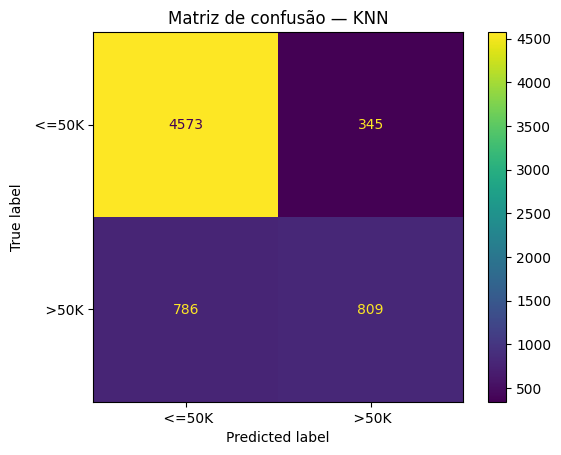


REGRESSÃO LOGÍSTICA
Acurácia: 84.69%

Relatório:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      4918
        >50K       0.72      0.61      0.66      1595

    accuracy                           0.85      6513
   macro avg       0.80      0.77      0.78      6513
weighted avg       0.84      0.85      0.84      6513



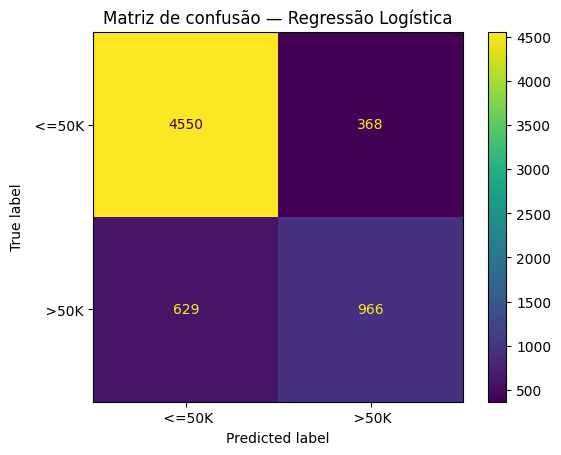


COMPARAÇÃO FINAL
KNN: 82.63%
Regressão Logística: 84.69%


In [762]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


# =========================================================
# 1. CARREGAR A BASE
# =========================================================

base_census = pd.read_csv('census.csv')


# =========================================================
# 2. SEPARAR FEATURES E TARGET
# =========================================================

X_census = base_census.iloc[:, 0:14].values
y_census = base_census.iloc[:, 14].values


# =========================================================
# 3. LABEL ENCODING
# =========================================================

colunas_categoricas = [
    1,   # workclass
    3,   # education
    5,   # marital-status
    6,   # occupation
    7,   # relationship
    8,   # race
    9,   # sex
    13   # native-country
]

for coluna in colunas_categoricas:
    encoder = LabelEncoder()

    X_census[:, coluna] = encoder.fit_transform(
        X_census[:, coluna]
    )


# =========================================================
# 4. ONE-HOT ENCODING
# =========================================================

onehotencoder_census = ColumnTransformer(
    transformers=[
        (
            'OneHot',
            OneHotEncoder(),
            colunas_categoricas
        )
    ],
    remainder='passthrough'
)

X_census = onehotencoder_census.fit_transform(
    X_census
)


# =========================================================
# 5. STANDARD SCALER
# =========================================================

scaler_census = StandardScaler(
    with_mean=False
)

X_census = scaler_census.fit_transform(
    X_census
)


# =========================================================
# 6. TREINAMENTO E TESTE
# =========================================================

X_census_treinamento, X_census_teste, y_census_treinamento, y_census_teste = train_test_split(
    X_census,
    y_census,
    test_size=0.2,
    random_state=0
)


# =========================================================
# 7. KNN
# =========================================================

knn_census = KNeighborsClassifier(
    n_neighbors=10
)

knn_census.fit(
    X_census_treinamento,
    y_census_treinamento
)

previsoes_knn = knn_census.predict(
    X_census_teste
)

acuracia_knn = accuracy_score(
    y_census_teste,
    previsoes_knn
)

matriz_knn = confusion_matrix(
    y_census_teste,
    previsoes_knn,
    labels=knn_census.classes_
)

print('\nKNN')
print(f'Acurácia: {acuracia_knn * 100:.2f}%')

print('\nRelatório:')
print(
    classification_report(
        y_census_teste,
        previsoes_knn
    )
)

ConfusionMatrixDisplay(
    confusion_matrix=matriz_knn,
    display_labels=knn_census.classes_
).plot()

plt.title('Matriz de confusão — KNN')
plt.show()


# =========================================================
# 8. REGRESSÃO LOGÍSTICA
# =========================================================

logistic_census = LogisticRegression(
    random_state=1,
    max_iter=100
)

logistic_census.fit(
    X_census_treinamento,
    y_census_treinamento
)

previsoes_logistica = logistic_census.predict(
    X_census_teste
)

acuracia_logistica = accuracy_score(
    y_census_teste,
    previsoes_logistica
)

matriz_logistica = confusion_matrix(
    y_census_teste,
    previsoes_logistica,
    labels=logistic_census.classes_
)

print('\nREGRESSÃO LOGÍSTICA')
print(f'Acurácia: {acuracia_logistica * 100:.2f}%')

print('\nRelatório:')
print(
    classification_report(
        y_census_teste,
        previsoes_logistica
    )
)

ConfusionMatrixDisplay(
    confusion_matrix=matriz_logistica,
    display_labels=logistic_census.classes_
).plot()

plt.title('Matriz de confusão — Regressão Logística')
plt.show()


# =========================================================
# 9. COMPARAÇÃO
# =========================================================

print('\nCOMPARAÇÃO FINAL')

print(
    f'KNN: {acuracia_knn * 100:.2f}%'
)

print(
    f'Regressão Logística: '
    f'{acuracia_logistica * 100:.2f}%'
)

# SupportVectorMachine - SVA

Acurácia: 98.80%
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       436
           1       0.97      0.94      0.95        64

    accuracy                           0.99       500
   macro avg       0.98      0.97      0.97       500
weighted avg       0.99      0.99      0.99       500

[[434   2]
 [  4  60]]


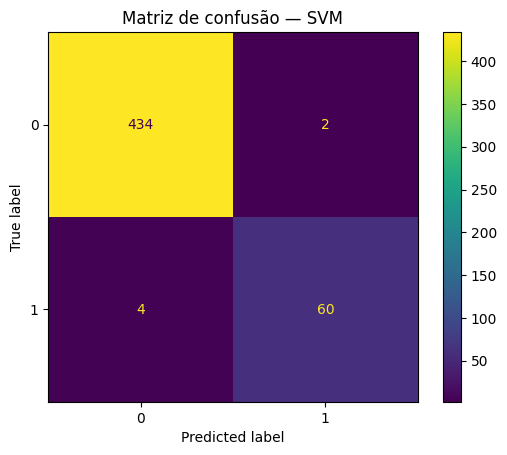

In [763]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# 1. Carregar a base
base_credit = pd.read_csv('credit_data.csv')


# 2. Calcular a média das idades válidas
media_idades = base_credit.loc[
    base_credit['age'] > 0,
    'age'
].mean()


# 3. Corrigir idades negativas
base_credit.loc[
    base_credit['age'] < 0,
    'age'
] = media_idades


# 4. Preencher idades nulas
base_credit['age'] = base_credit['age'].fillna(
    base_credit['age'].mean()
)


# 5. Separar features e target
X_credit = base_credit.iloc[:, 1:4].values
y_credit = base_credit.iloc[:, 4].values


# 6. Separar treinamento e teste
X_credit_treinamento, X_credit_teste, y_credit_treinamento, y_credit_teste = train_test_split(
    X_credit,
    y_credit,
    test_size=0.25,
    random_state=0
)


# 7. Padronizar
scaler_credit = StandardScaler()

X_credit_treinamento = scaler_credit.fit_transform(
    X_credit_treinamento
)

X_credit_teste = scaler_credit.transform(
    X_credit_teste
)


# 8. Criar o SVM
svm_credit = SVC(
    kernel='rbf',
    C=2
)


# 9. Treinar
svm_credit.fit(
    X_credit_treinamento,
    y_credit_treinamento
)


# 10. Prever
previsoes_svm = svm_credit.predict(
    X_credit_teste
)


# 11. Acurácia
acuracia_svm = accuracy_score(
    y_credit_teste,
    previsoes_svm
)

print(f'Acurácia: {acuracia_svm * 100:.2f}%')


# 12. Relatório de classificação
print(
    classification_report(
        y_credit_teste,
        previsoes_svm
    )
)


# 13. Matriz de confusão
matriz_svm = confusion_matrix(
    y_credit_teste,
    previsoes_svm,
    labels=svm_credit.classes_
)

print(matriz_svm)

ConfusionMatrixDisplay(
    confusion_matrix=matriz_svm,
    display_labels=svm_credit.classes_
).plot()

plt.title('Matriz de confusão — SVM')
plt.show()

In [764]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. CARREGAR O DATASET
# ============================================================

df = pd.read_csv(
    'base_segundo_encontro.csv',
    sep=';',
    encoding='latin1'
)

print(df.head())
print('\nFormato da base:', df.shape)

print('\nValores nulos:')
print(df.isnull().sum())

print('\nDistribuição do target:')
print(df['segundo_encontro'].value_counts())


# ============================================================
# 2. SEPARAR FEATURES E TARGET
# ============================================================

X = df.drop(
    'segundo_encontro',
    axis=1
)

y = df['segundo_encontro']


# Features categóricas
colunas_categoricas = [
    'local_encontro',
    'momento_da_vida'
]


# Features numéricas
colunas_numericas = [
    'tempo_conversa_min',
    'risadas',
    'pontos_comuns',
    'nivel_timidez',
    'mensagens_antes',
    'iniciativa_conversa'
]


# ============================================================
# 3. SEPARAR TREINAMENTO E TESTE
# ============================================================

X_treinamento, X_teste, y_treinamento, y_teste = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('\nFormato do treinamento:')
print(X_treinamento.shape)

print('\nFormato do teste:')
print(X_teste.shape)


# ============================================================
# 4. APLICAR ONE-HOT ENCODING
# ============================================================

encoder = ColumnTransformer(
    transformers=[
        (
            'OneHot',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            colunas_categoricas
        )
    ],
    remainder='passthrough'
)


# Aprende as categorias e transforma o treinamento
X_treinamento_encoded = encoder.fit_transform(
    X_treinamento
)


# Apenas transforma o teste
X_teste_encoded = encoder.transform(
    X_teste
)

print('\nFormato após o One-Hot Encoding:')
print(X_treinamento_encoded.shape)


# ============================================================
# 5. PADRONIZAR OS DADOS
# ============================================================

# with_mean=False porque o OneHotEncoder gera uma matriz esparsa
scaler = StandardScaler(
    with_mean=False
)


# Aprende a escala com o treinamento
X_treinamento_padronizado = scaler.fit_transform(
    X_treinamento_encoded
)


# Aplica a mesma escala ao teste
X_teste_padronizado = scaler.transform(
    X_teste_encoded
)


# ============================================================
# 6. TESTAR TODOS OS KERNELS E VALORES DE C
# ============================================================

kernels = [
    'linear',
    'rbf',
    'poly',
    'sigmoid'
]

valores_c = [
    0.1,
    1,
    2,
    10
]

resultados = []


for kernel in kernels:

    for valor_c in valores_c:

        modelo = SVC(
            kernel=kernel,
            C=valor_c
        )

        modelo.fit(
            X_treinamento_padronizado,
            y_treinamento
        )

        previsoes = modelo.predict(
            X_teste_padronizado
        )

        acuracia = accuracy_score(
            y_teste,
            previsoes
        )

        resultados.append({
            'kernel': kernel,
            'C': valor_c,
            'acuracia': acuracia
        })


# ============================================================
# 7. COMPARAR OS RESULTADOS AUTOMATICAMENTE
# ============================================================

resultados_df = pd.DataFrame(
    resultados
)

resultados_df = resultados_df.sort_values(
    by='acuracia',
    ascending=False
).reset_index(drop=True)

resultados_df['acuracia_percentual'] = (
    resultados_df['acuracia'] * 100
).round(2)

print('\nResultados dos modelos:')

print(
    resultados_df[
        [
            'kernel',
            'C',
            'acuracia_percentual'
        ]
    ]
)


# Selecionar automaticamente o melhor resultado
melhor_kernel = resultados_df.loc[
    0,
    'kernel'
]

melhor_c = resultados_df.loc[
    0,
    'C'
]

melhor_acuracia = resultados_df.loc[
    0,
    'acuracia'
]

print('\nMelhor configuração encontrada:')

print('Kernel:', melhor_kernel)
print('C:', melhor_c)

print(
    f'Acurácia: '
    f'{melhor_acuracia * 100:.2f}%'
)


# ============================================================
# 8. TREINAR NOVAMENTE O MELHOR MODELO
# ============================================================

melhor_modelo = SVC(
    kernel=melhor_kernel,
    C=melhor_c
)

melhor_modelo.fit(
    X_treinamento_padronizado,
    y_treinamento
)


# Previsões do melhor modelo
melhores_previsoes = melhor_modelo.predict(
    X_teste_padronizado
)


# ============================================================
# 9. MÉTRICAS DO MELHOR MODELO
# ============================================================

print('\nMatriz de confusão:')

matriz = confusion_matrix(
    y_teste,
    melhores_previsoes,
    labels=['Não', 'Sim']
)

print(matriz)


print('\nRelatório de classificação:')

print(
    classification_report(
        y_teste,
        melhores_previsoes
    )
)


# ============================================================
# 10. FUNÇÕES PARA RECEBER AS ENTRADAS DO USUÁRIO
# ============================================================

def ler_inteiro(mensagem, minimo, maximo):

    while True:

        try:
            valor = int(
                input(mensagem)
            )

            if minimo <= valor <= maximo:
                return valor

            print(
                f'Digite um valor entre '
                f'{minimo} e {maximo}.'
            )

        except ValueError:
            print('Digite um número inteiro válido.')


def escolher_opcao(mensagem, opcoes):

    print(f'\n{mensagem}')

    for numero, opcao in enumerate(
        opcoes,
        start=1
    ):
        print(f'{numero} - {opcao}')

    while True:

        try:
            escolha = int(
                input('Escolha uma opção: ')
            )

            if 1 <= escolha <= len(opcoes):
                return opcoes[escolha - 1]

            print('Escolha uma opção válida.')

        except ValueError:
            print('Digite o número da opção.')


# ============================================================
# 11. RECEBER AS INFORMAÇÕES DO NOVO ENCONTRO
# ============================================================

print('\n--- DADOS DO ENCONTRO ---')


tempo_conversa = ler_inteiro(
    'Duração da conversa em minutos (10 a 149): ',
    10,
    149
)

risadas = ler_inteiro(
    'Quantidade de risadas (0 a 19): ',
    0,
    19
)

pontos_comuns = ler_inteiro(
    'Quantidade de pontos em comum (0 a 10): ',
    0,
    10
)

nivel_timidez = ler_inteiro(
    'Nível de timidez (0 a 10): ',
    0,
    10
)

mensagens_antes = ler_inteiro(
    'Quantidade de mensagens antes do encontro (0 a 49): ',
    0,
    49
)

iniciativa_conversa = ler_inteiro(
    'Iniciativa na conversa (0 a 10): ',
    0,
    10
)


local_encontro = escolher_opcao(
    'Local do encontro:',
    [
        'Café',
        'Restaurante',
        'Parque',
        'Bar'
    ]
)


momento_da_vida = escolher_opcao(
    'Momento da vida:',
    [
        'Estável',
        'Estressado',
        'Cansado'
    ]
)


# ============================================================
# 12. CRIAR O NOVO REGISTRO
# ============================================================

novo_encontro = pd.DataFrame({
    'tempo_conversa_min': [tempo_conversa],
    'risadas': [risadas],
    'pontos_comuns': [pontos_comuns],
    'nivel_timidez': [nivel_timidez],
    'mensagens_antes': [mensagens_antes],
    'iniciativa_conversa': [iniciativa_conversa],
    'local_encontro': [local_encontro],
    'momento_da_vida': [momento_da_vida]
})


print('\nDados informados:')

print(
    novo_encontro.to_string(
        index=False
    )
)


# ============================================================
# 13. APLICAR OS MESMOS TRATAMENTOS
# ============================================================

# Não usamos fit_transform no novo registro
novo_encontro_encoded = encoder.transform(
    novo_encontro
)

novo_encontro_padronizado = scaler.transform(
    novo_encontro_encoded
)


# ============================================================
# 14. REALIZAR A PREVISÃO
# ============================================================

previsao_final = melhor_modelo.predict(
    novo_encontro_padronizado
)

resultado = previsao_final[0]


print('\n--- RESULTADO ---')

if resultado == 'Sim':

    print(
        'Segundo o modelo, haverá um segundo encontro.'
    )

else:

    print(
        'Segundo o modelo, não haverá um segundo encontro.'
    )

   tempo_conversa_min  risadas  ...  momento_da_vida  segundo_encontro
0                 112       16  ...       Estressado               Sim
1                 102       13  ...          Estável               Sim
2                  24        8  ...          Estável               Sim
3                 116        7  ...       Estressado               Sim
4                  81        1  ...          Estável               Não

[5 rows x 9 columns]

Formato da base: (1000, 9)

Valores nulos:
tempo_conversa_min     0
risadas                0
pontos_comuns          0
nivel_timidez          0
mensagens_antes        0
iniciativa_conversa    0
local_encontro         0
momento_da_vida        0
segundo_encontro       0
dtype: int64

Distribuição do target:
segundo_encontro
Sim    759
Não    241
Name: count, dtype: int64

Formato do treinamento:
(800, 8)

Formato do teste:
(200, 8)

Formato após o One-Hot Encoding:
(800, 13)

Resultados dos modelos:
     kernel     C  acuracia_percentual
0    linea

# Otimizações

### SVM

Classes:
['malignant' 'benign']

Formato de X:
(569, 30)

Formato de y:
(569,)

Acurácia: 95.80%

Relatório de classificação:
              precision    recall  f1-score   support

   malignant       0.94      0.94      0.94        53
      benign       0.97      0.97      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.96      0.96      0.96       143


Matriz de confusão:
[[50  3]
 [ 3 87]]


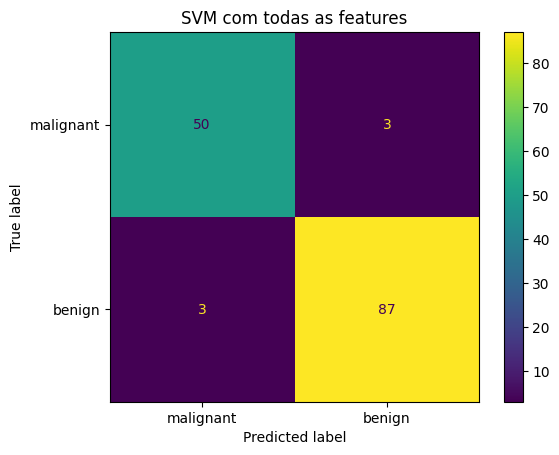

In [765]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. CARREGAR A BASE
# ============================================================

dados = load_breast_cancer()

X = dados.data
y = dados.target

print('Classes:')
print(dados.target_names)

print('\nFormato de X:')
print(X.shape)

print('\nFormato de y:')
print(y.shape)


# ============================================================
# 2. SEPARAR TREINAMENTO E TESTE
# ============================================================

X_treinamento, X_teste, y_treinamento, y_teste = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=0,
    stratify=y
)


# ============================================================
# 3. PADRONIZAR OS DADOS
# ============================================================

scaler = StandardScaler()

X_treinamento = scaler.fit_transform(
    X_treinamento
)

X_teste = scaler.transform(
    X_teste
)


# ============================================================
# 4. CRIAR O SVM
# ============================================================

svm = SVC(
    kernel='linear',
    C=2
)


# ============================================================
# 5. TREINAR
# ============================================================

svm.fit(
    X_treinamento,
    y_treinamento
)


# ============================================================
# 6. PREVER
# ============================================================

previsoes = svm.predict(
    X_teste
)


# ============================================================
# 7. AVALIAR
# ============================================================

acuracia = accuracy_score(
    y_teste,
    previsoes
)

print(f'\nAcurácia: {acuracia * 100:.2f}%')

print('\nRelatório de classificação:')

print(
    classification_report(
        y_teste,
        previsoes,
        target_names=dados.target_names
    )
)


# ============================================================
# 8. MATRIZ DE CONFUSÃO
# ============================================================

matriz = confusion_matrix(
    y_teste,
    previsoes
)

print('\nMatriz de confusão:')
print(matriz)

ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=dados.target_names
).plot()

plt.title('SVM com todas as features')
plt.show()

### pca

Formato original do treinamento:
(426, 30)

Formato após o PCA:
(426, 5)

Variância explicada por componente:
[0.44481246 0.18928593 0.09446603 0.06588143 0.05276615]

Variância total explicada:
0.8472119971185881

Acurácia com PCA: 95.80%

Relatório de classificação:
              precision    recall  f1-score   support

   malignant       0.93      0.96      0.94        53
      benign       0.98      0.96      0.97        90

    accuracy                           0.96       143
   macro avg       0.95      0.96      0.96       143
weighted avg       0.96      0.96      0.96       143



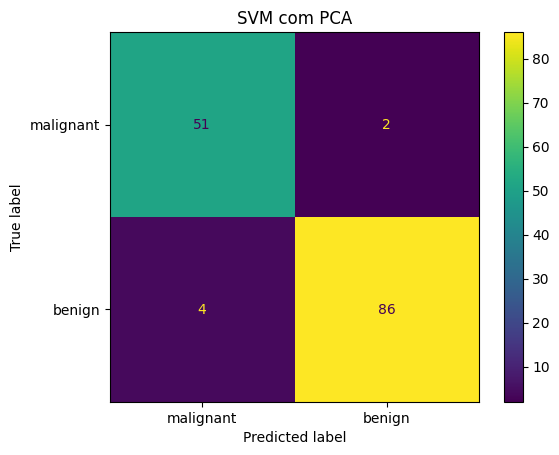

In [766]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. CARREGAR A BASE
# ============================================================

dados = load_breast_cancer()

X = dados.data
y = dados.target


# ============================================================
# 2. SEPARAR TREINAMENTO E TESTE
# ============================================================

X_treinamento, X_teste, y_treinamento, y_teste = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=0,
    stratify=y
)


# ============================================================
# 3. PADRONIZAÇÃO
# ============================================================

scaler = StandardScaler()

X_treinamento = scaler.fit_transform(
    X_treinamento
)

X_teste = scaler.transform(
    X_teste
)


# ============================================================
# 4. CRIAR O PCA
# ============================================================

pca = PCA(
    n_components=5
)


# ============================================================
# 5. TRANSFORMAR O TREINAMENTO
# ============================================================

X_treinamento_pca = pca.fit_transform(
    X_treinamento
)


# ============================================================
# 6. TRANSFORMAR O TESTE
# ============================================================

X_teste_pca = pca.transform(
    X_teste
)


# ============================================================
# 7. VERIFICAR OS FORMATOS
# ============================================================

print('Formato original do treinamento:')
print(X_treinamento.shape)

print('\nFormato após o PCA:')
print(X_treinamento_pca.shape)

print('\nVariância explicada por componente:')
print(pca.explained_variance_ratio_)

print('\nVariância total explicada:')
print(pca.explained_variance_ratio_.sum())


# ============================================================
# 8. CRIAR E TREINAR O SVM
# ============================================================

svm_pca = SVC(
    kernel='linear',
    C=2
)

svm_pca.fit(
    X_treinamento_pca,
    y_treinamento
)


# ============================================================
# 9. PREVER
# ============================================================

previsoes_pca = svm_pca.predict(
    X_teste_pca
)


# ============================================================
# 10. AVALIAR
# ============================================================

acuracia_pca = accuracy_score(
    y_teste,
    previsoes_pca
)

print(f'\nAcurácia com PCA: {acuracia_pca * 100:.2f}%')

print('\nRelatório de classificação:')

print(
    classification_report(
        y_teste,
        previsoes_pca,
        target_names=dados.target_names
    )
)


# ============================================================
# 11. MATRIZ DE CONFUSÃO
# ============================================================

matriz_pca = confusion_matrix(
    y_teste,
    previsoes_pca
)

ConfusionMatrixDisplay(
    confusion_matrix=matriz_pca,
    display_labels=dados.target_names
).plot()

plt.title('SVM com PCA')
plt.show()

### selectkbest

Features selecionadas pela ANOVA:
mean radius
mean perimeter
mean concave points
worst radius
worst perimeter
worst area
worst concave points

Formato original:
(398, 30)

Formato após a seleção:
(398, 7)

Acurácia com ANOVA: 95.91%

Relatório de classificação:
              precision    recall  f1-score   support

   malignant       0.97      0.92      0.94        64
      benign       0.95      0.98      0.97       107

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



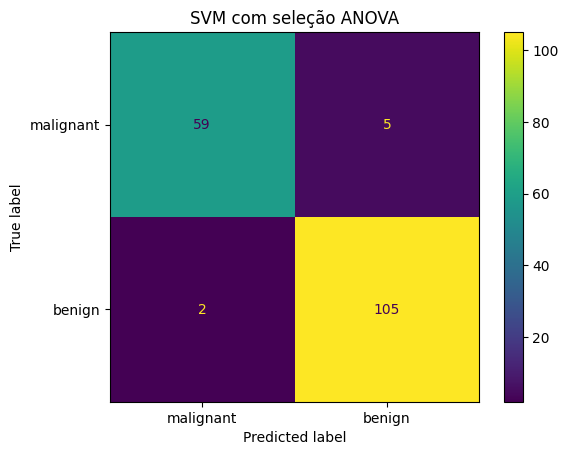

In [767]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. CARREGAR A BASE
# ============================================================

dados = load_breast_cancer()

X = dados.data
y = dados.target

nomes_features = dados.feature_names


# ============================================================
# 2. SEPARAR TREINAMENTO E TESTE
# ============================================================

X_treinamento, X_teste, y_treinamento, y_teste = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=0,
    stratify=y
)


# ============================================================
# 3. CRIAR O SELETOR ANOVA
# ============================================================

seletor = SelectKBest(
    score_func=f_classif,
    k=7
)


# ============================================================
# 4. SELECIONAR FEATURES NO TREINAMENTO
# ============================================================

X_treinamento_anova = seletor.fit_transform(
    X_treinamento,
    y_treinamento
)


# ============================================================
# 5. APLICAR A MESMA SELEÇÃO AO TESTE
# ============================================================

X_teste_anova = seletor.transform(
    X_teste
)


# ============================================================
# 6. MOSTRAR AS FEATURES ESCOLHIDAS
# ============================================================

features_selecionadas = nomes_features[
    seletor.get_support()
]

print('Features selecionadas pela ANOVA:')

for feature in features_selecionadas:
    print(feature)

print('\nFormato original:')
print(X_treinamento.shape)

print('\nFormato após a seleção:')
print(X_treinamento_anova.shape)


# ============================================================
# 7. PADRONIZAR AS FEATURES SELECIONADAS
# ============================================================

scaler = StandardScaler()

X_treinamento_anova = scaler.fit_transform(
    X_treinamento_anova
)

X_teste_anova = scaler.transform(
    X_teste_anova
)


# ============================================================
# 8. CRIAR E TREINAR O SVM
# ============================================================

svm_anova = SVC(
    kernel='linear',
    C=2
)

svm_anova.fit(
    X_treinamento_anova,
    y_treinamento
)


# ============================================================
# 9. PREVER
# ============================================================

previsoes_anova = svm_anova.predict(
    X_teste_anova
)


# ============================================================
# 10. AVALIAR
# ============================================================

acuracia_anova = accuracy_score(
    y_teste,
    previsoes_anova
)

print(f'\nAcurácia com ANOVA: {acuracia_anova * 100:.2f}%')

print('\nRelatório de classificação:')

print(
    classification_report(
        y_teste,
        previsoes_anova,
        target_names=dados.target_names
    )
)


# ============================================================
# 11. MATRIZ DE CONFUSÃO
# ============================================================

matriz_anova = confusion_matrix(
    y_teste,
    previsoes_anova
)

ConfusionMatrixDisplay(
    confusion_matrix=matriz_anova,
    display_labels=dados.target_names
).plot()

plt.title('SVM com seleção ANOVA')
plt.show()

### grid search svm

In [768]:
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV


# ============================================================
# 1. CARREGAR A BASE
# ============================================================

dados = load_breast_cancer()

X = dados.data
y = dados.target


# ============================================================
# 2. PADRONIZAR
# ============================================================

scaler = StandardScaler()

X = scaler.fit_transform(
    X
)


# ============================================================
# 3. DEFINIR OS HIPERPARÂMETROS
# ============================================================

parametros = {
    'C': [
        1.0,
        1.5,
        2.0
    ],

    'kernel': [
        'rbf',
        'linear',
        'poly',
        'sigmoid'
    ]
}


# ============================================================
# 4. CRIAR O GRID SEARCH
# ============================================================

grid_search_svm = GridSearchCV(
    estimator=SVC(),
    param_grid=parametros,
    scoring='accuracy',
    cv=5,
    return_train_score=True
)


# ============================================================
# 5. EXECUTAR OS TESTES
# ============================================================

grid_search_svm.fit(
    X,
    y
)


# ============================================================
# 6. MELHORES RESULTADOS
# ============================================================

print('Melhores parâmetros:')
print(grid_search_svm.best_params_)

print('\nMelhor acurácia média:')

print(
    f'{grid_search_svm.best_score_ * 100:.2f}%'
)


# ============================================================
# 7. TODOS OS RESULTADOS
# ============================================================

resultados = pd.DataFrame(
    grid_search_svm.cv_results_
)

colunas_resultado = [
    'param_C',
    'param_kernel',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]

resultados = resultados[
    colunas_resultado
].sort_values(
    by='rank_test_score'
)

resultados['mean_test_score'] = (
    resultados['mean_test_score'] * 100
)

resultados['std_test_score'] = (
    resultados['std_test_score'] * 100
)

print('\nResultados completos:')
print(resultados.to_string(index=False))

Melhores parâmetros:
{'C': 1.5, 'kernel': 'rbf'}

Melhor acurácia média:
97.72%

Resultados completos:
 param_C param_kernel  mean_test_score  std_test_score  rank_test_score
     1.5          rbf        97.716193        1.311632                1
     2.0          rbf        97.540755        1.020861                2
     1.0          rbf        97.363763        1.467854                3
     1.5       linear        97.014439        1.049021                4
     2.0       linear        97.014439        0.696327                4
     1.0       linear        97.014439        1.049021                4
     1.0      sigmoid        95.960255        1.886092                7
     1.5      sigmoid        94.376650        0.891098                8
     2.0      sigmoid        93.850334        2.771043                9
     2.0         poly        91.922062        2.555325               10
     1.5         poly        91.218755        2.467938               11
     1.0         poly        89.8

### grid search random forest

In [769]:
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV


# ============================================================
# 1. CARREGAR A BASE
# ============================================================

dados = load_breast_cancer()

X = dados.data
y = dados.target


# ============================================================
# 2. DEFINIR OS HIPERPARÂMETROS
# ============================================================

parametros = {
    'n_estimators': [
        10,
        40,
        100,
        150,
        200
    ]
}


# ============================================================
# 3. CRIAR O GRID SEARCH
# ============================================================

grid_search_random_forest = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=0
    ),
    param_grid=parametros,
    scoring='accuracy',
    cv=5
)


# ============================================================
# 4. EXECUTAR
# ============================================================

grid_search_random_forest.fit(
    X,
    y
)


# ============================================================
# 5. MOSTRAR O MELHOR RESULTADO
# ============================================================

print('Melhores parâmetros:')

print(
    grid_search_random_forest.best_params_
)

print('\nMelhor acurácia média:')

print(
    f'{grid_search_random_forest.best_score_ * 100:.2f}%'
)


# ============================================================
# 6. MOSTRAR TODOS OS RESULTADOS
# ============================================================

resultados = pd.DataFrame(
    grid_search_random_forest.cv_results_
)

resultados = resultados[
    [
        'param_n_estimators',
        'mean_test_score',
        'std_test_score',
        'rank_test_score'
    ]
].sort_values(
    by='rank_test_score'
)

resultados['mean_test_score'] = (
    resultados['mean_test_score'] * 100
)

print('\nResultados:')
print(resultados.to_string(index=False))

Melhores parâmetros:
{'n_estimators': 40}

Melhor acurácia média:
96.49%

Resultados:
 param_n_estimators  mean_test_score  std_test_score  rank_test_score
                 40        96.486570        0.014651                1
                100        96.311132        0.021749                2
                150        95.960255        0.023899                3
                200        95.960255        0.018861                3
                 10        95.432386        0.025639                5


### grid search knn

In [770]:
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV


# ============================================================
# 1. CARREGAR A BASE
# ============================================================

dados = load_breast_cancer()

X = dados.data
y = dados.target


# ============================================================
# 2. PADRONIZAR
# ============================================================

scaler = StandardScaler()

X = scaler.fit_transform(
    X
)


# ============================================================
# 3. HIPERPARÂMETROS
# ============================================================

parametros = {
    'n_neighbors': [
        3,
        5,
        10,
        20
    ]
}


# ============================================================
# 4. GRID SEARCH
# ============================================================

grid_search_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=parametros,
    scoring='accuracy',
    cv=5
)


# ============================================================
# 5. EXECUTAR
# ============================================================

grid_search_knn.fit(
    X,
    y
)


# ============================================================
# 6. RESULTADOS
# ============================================================

print('Melhores parâmetros:')

print(
    grid_search_knn.best_params_
)

print('\nMelhor acurácia média:')

print(
    f'{grid_search_knn.best_score_ * 100:.2f}%'
)


# ============================================================
# 7. TODOS OS RESULTADOS
# ============================================================

resultados = pd.DataFrame(
    grid_search_knn.cv_results_
)

resultados = resultados[
    [
        'param_n_neighbors',
        'mean_test_score',
        'std_test_score',
        'rank_test_score'
    ]
].sort_values(
    by='rank_test_score'
)

resultados['mean_test_score'] = (
    resultados['mean_test_score'] * 100
)

print('\nResultados:')
print(resultados.to_string(index=False))

Melhores parâmetros:
{'n_neighbors': 10}

Melhor acurácia média:
96.49%

Resultados:
 param_n_neighbors  mean_test_score  std_test_score  rank_test_score
                10        96.486570        0.017521                1
                 5        96.485018        0.009610                2
                 3        95.777053        0.018919                3
                20        95.258500        0.019643                4


### cross validation para svm

In [771]:
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.model_selection import (
    KFold,
    cross_val_score
)


# ============================================================
# 1. CARREGAR A BASE
# ============================================================

dados = load_breast_cancer()

X = dados.data
y = dados.target


# ============================================================
# 2. PADRONIZAR
# ============================================================

scaler = StandardScaler()

X = scaler.fit_transform(
    X
)


# ============================================================
# 3. LISTA PARA ARMAZENAR OS RESULTADOS
# ============================================================

resultados_svm = []


# ============================================================
# 4. REPETIR O K-FOLD 30 VEZES
# ============================================================

for i in range(30):

    kfold = KFold(
        n_splits=10,
        shuffle=True,
        random_state=i
    )

    svm = SVC(
        kernel='rbf',
        C=1.5
    )

    scores = cross_val_score(
        svm,
        X,
        y,
        cv=kfold,
        scoring='accuracy'
    )

    media_execucao = scores.mean()

    resultados_svm.append(
        media_execucao
    )

    print(
        f'Execução {i + 1:02d}: '
        f'{media_execucao * 100:.2f}%'
    )


# ============================================================
# 5. RESULTADO FINAL
# ============================================================

media_geral = np.mean(
    resultados_svm
)

desvio_padrao = np.std(
    resultados_svm
)

print('\nResultado final:')

print(
    f'Média das acurácias: '
    f'{media_geral * 100:.2f}%'
)

print(
    f'Desvio-padrão: '
    f'{desvio_padrao * 100:.4f} pontos percentuais'
)

print(
    f'Quantidade total de treinamentos: '
    f'{30 * 10}'
)

Execução 01: 97.89%
Execução 02: 97.36%
Execução 03: 97.54%
Execução 04: 97.54%
Execução 05: 97.71%
Execução 06: 97.36%
Execução 07: 98.07%
Execução 08: 97.19%
Execução 09: 97.19%
Execução 10: 97.54%
Execução 11: 97.89%
Execução 12: 97.89%
Execução 13: 97.72%
Execução 14: 97.72%
Execução 15: 98.07%
Execução 16: 97.72%
Execução 17: 98.07%
Execução 18: 97.54%
Execução 19: 97.71%
Execução 20: 97.37%
Execução 21: 97.54%
Execução 22: 97.54%
Execução 23: 97.53%
Execução 24: 97.89%
Execução 25: 97.89%
Execução 26: 97.71%
Execução 27: 97.19%
Execução 28: 97.89%
Execução 29: 97.53%
Execução 30: 97.72%

Resultado final:
Média das acurácias: 97.65%
Desvio-padrão: 0.2505 pontos percentuais
Quantidade total de treinamentos: 300
